<a href="https://colab.research.google.com/github/JaaynyDasari/Fake-News-Detection/blob/master/Fake_News_Detection_ADS_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
true_df = pd.read_csv('/content/drive/MyDrive/ADS FINAL PROJECT/True.csv')
fake_df = pd.read_csv('/content/drive/MyDrive/ADS FINAL PROJECT/Fake.csv')

true_df['label'] = 1
fake_df['label'] = 0

df = pd.concat([true_df, fake_df], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop unnecessary columns
df.drop(['date', 'subject'], axis=1, inplace=True)

# Handle missing values
print("Missing values:\n", df.isnull().sum())

# Drop rows with missing title or text
df.dropna(subset=['title', 'text'], inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

print(f"\nFinal dataset shape: {df.shape}")


Missing values:
 title    0
text     0
label    0
dtype: int64

Final dataset shape: (39105, 3)


In [ ]:
import re
import string
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine title and text
df['content'] = df['title'] + " " + df['text']
df.drop(['title', 'text'], axis=1, inplace=True)

# Download stopwords (only once)
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply cleaning
df['cleaned_content'] = df['content'].apply(clean_text)

print(df[['cleaned_content', 'label']].head(2))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                     cleaned_content  label
0  breaking gop chairman grassley enough demands ...      0
1  failed gop candidates remembered hilarious moc...      0


<ipython-input-10-338f200ac65a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


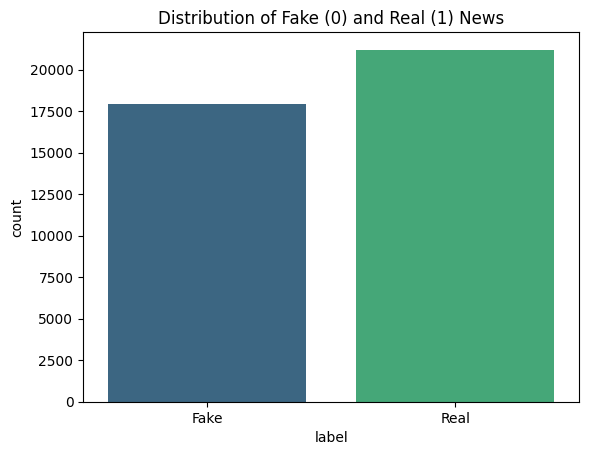

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Fake (0) and Real (1) News')
plt.xticks([0, 1], ['Fake', 'Real'])
plt.show()


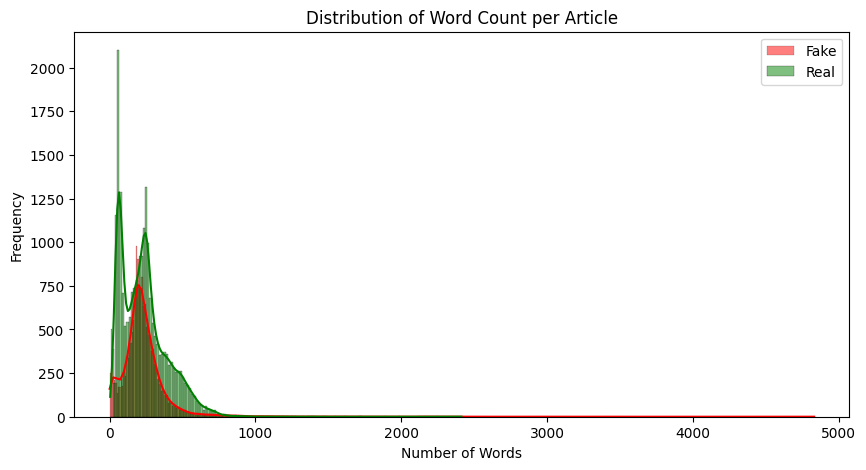

In [ ]:
# Add a column for content length
df['text_length'] = df['cleaned_content'].apply(lambda x: len(x.split()))

# Plot histogram of text lengths
plt.figure(figsize=(10,5))
sns.histplot(df[df['label'] == 0]['text_length'], color='red', label='Fake', kde=True)
sns.histplot(df[df['label'] == 1]['text_length'], color='green', label='Real', kde=True)
plt.legend()
plt.title("Distribution of Word Count per Article")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


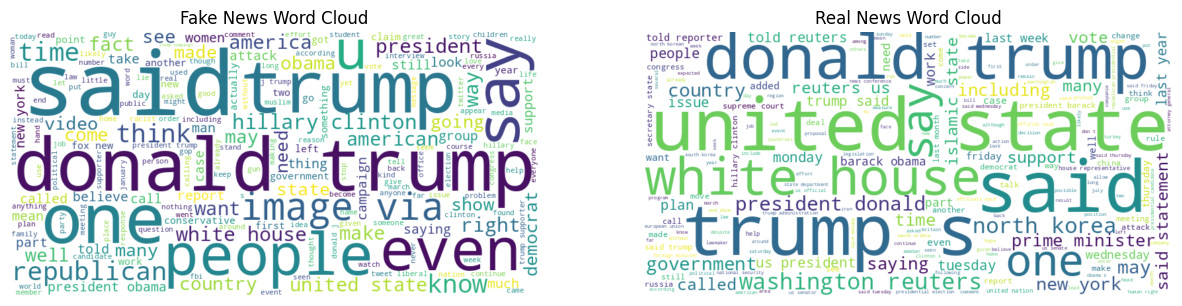

In [ ]:
from wordcloud import WordCloud

# Wordclouds
fake_words = ' '.join(df[df['label'] == 0]['cleaned_content'])
real_words = ' '.join(df[df['label'] == 1]['cleaned_content'])

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
wc = WordCloud(width=800, height=400, background_color='white').generate(fake_words)
plt.imshow(wc, interpolation='bilinear')
plt.title("Fake News Word Cloud")
plt.axis('off')

plt.subplot(1,2,2)
wc = WordCloud(width=800, height=400, background_color='white').generate(real_words)
plt.imshow(wc, interpolation='bilinear')
plt.title("Real News Word Cloud")
plt.axis('off')

plt.show()


<ipython-input-10-e10eb7d585c6>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(word_dict.values()), y=list(word_dict.keys()), palette='magma')


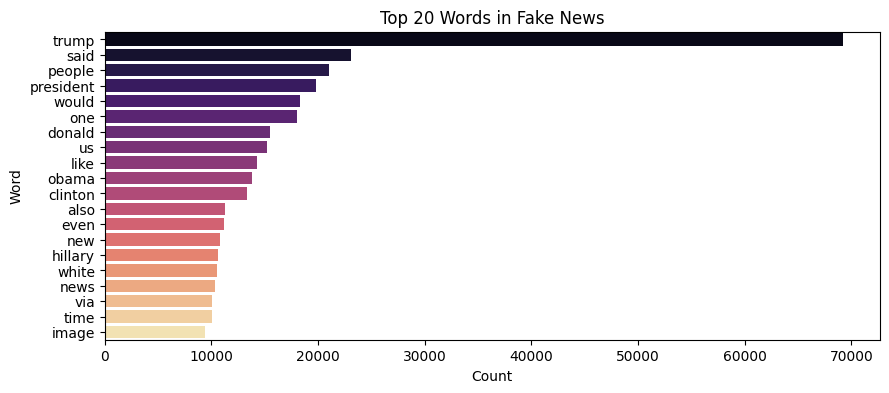

<ipython-input-10-e10eb7d585c6>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(word_dict.values()), y=list(word_dict.keys()), palette='magma')


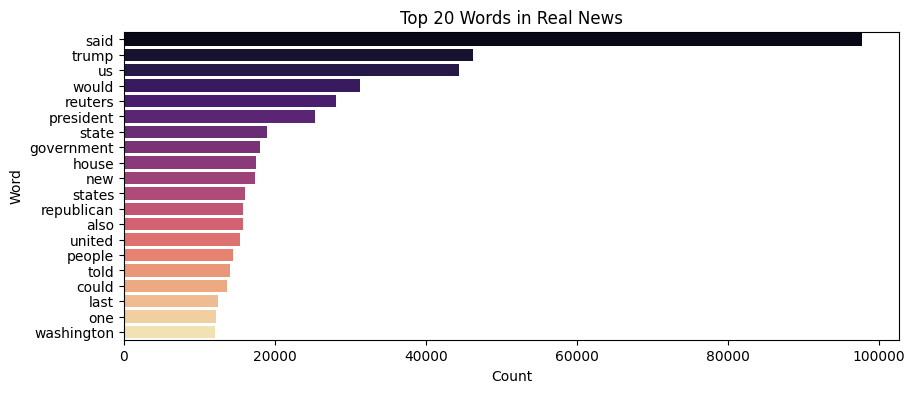

In [ ]:
from collections import Counter

# Tokenize
def get_top_n_words(corpus, n=None):
    words = ' '.join(corpus).split()
    most_common = Counter(words).most_common(n)
    return dict(most_common)

# Top words in fake news
fake_top_words = get_top_n_words(df[df['label']==0]['cleaned_content'], 20)
real_top_words = get_top_n_words(df[df['label']==1]['cleaned_content'], 20)

# Plot
def plot_top_words(word_dict, title):
    plt.figure(figsize=(10,4))
    sns.barplot(x=list(word_dict.values()), y=list(word_dict.keys()), palette='magma')
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

plot_top_words(fake_top_words, "Top 20 Words in Fake News")
plot_top_words(real_top_words, "Top 20 Words in Real News")


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF with 10000 features (you can reduce to 5000 if performance is a concern)
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['cleaned_content'])
y = df['label']


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Remove low-variance features
selector = VarianceThreshold(threshold=0.001)
X_variance = selector.fit_transform(X_tfidf)
print("Shape after Variance Threshold:", X_variance.shape)


Shape after Variance Threshold: (39105, 43)


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# Select top 3000 features
chi2_selector = SelectKBest(chi2, k=3000)
X_chi2 = chi2_selector.fit_transform(X_variance, y)
print("Shape after Chi-Square:", X_chi2.shape)


Shape after Chi-Square: (39105, 43)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=3000 is greater than n_features=43. All the features will be returned.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1

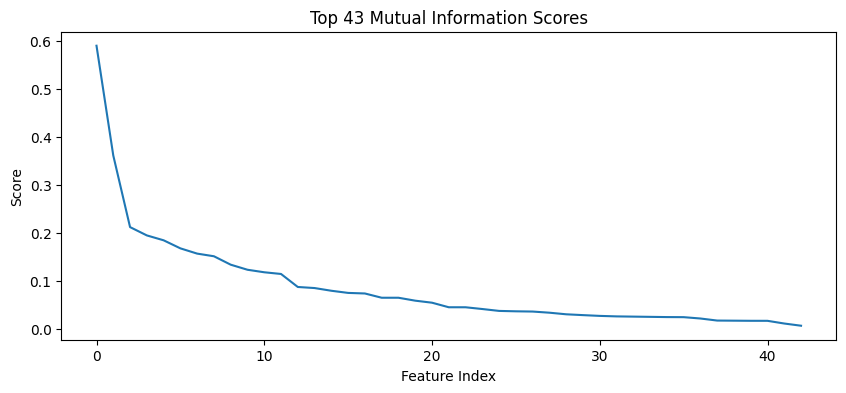

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

mi = mutual_info_classif(X_variance, y, discrete_features=True)
mi_scores = pd.Series(mi).sort_values(ascending=False)

# Get the length of mi_scores
num_scores = len(mi_scores)

# Use the minimum between 300 and num_scores for plotting
num_to_plot = min(300, num_scores)

plt.figure(figsize=(10, 4))
# Adjust x-axis range and y-data slice
sns.lineplot(x=np.arange(0, num_to_plot), y=mi_scores[:num_to_plot])
plt.title(f"Top {num_to_plot} Mutual Information Scores")
plt.xlabel("Feature Index")
plt.ylabel("Score")
plt.show()

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=500, step=100)
X_rfe = rfe.fit_transform(X_chi2, y)
print("Shape after RFE:", X_rfe.shape)


Shape after RFE: (39105, 43)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=500 > n_features=43. There will be no feature selection and all features will be kept.
  warnings.warn(


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42, stratify=y)


Accuracy: 0.8537271448663853
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      3582
           1       0.87      0.86      0.86      4239

    accuracy                           0.85      7821
   macro avg       0.85      0.85      0.85      7821
weighted avg       0.85      0.85      0.85      7821



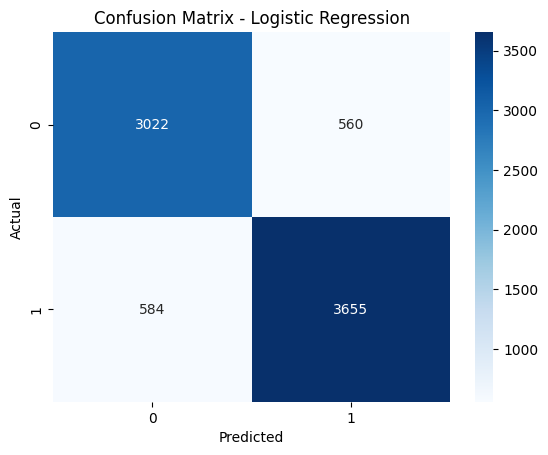

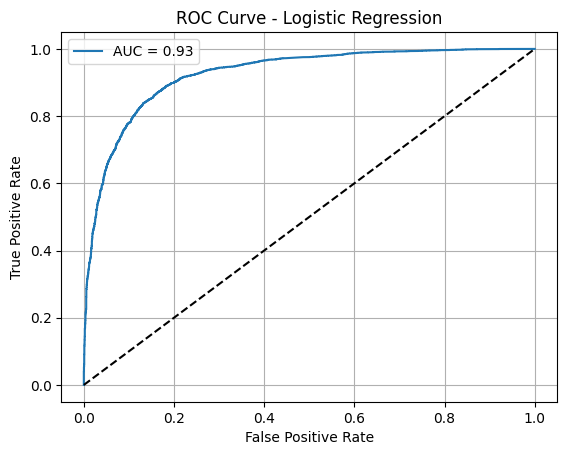

Prediction: Fake News


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Use the reduced feature set (after RFE)
X_train, X_test, y_train, y_test = train_test_split(X_rfe, y, test_size=0.2, random_state=42, stratify=y)

# Model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

# Accuracy & Report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()
def predict_news(model, vectorizer, news_text, selector, chi2_selector, rfe): # add new args
    cleaned = clean_text(news_text)
    # 1. Transform using the original vectorizer
    features = vectorizer.transform([cleaned])
    # 2. Apply the same feature selection steps
    features_variance = selector.transform(features)
    features_chi2 = chi2_selector.transform(features_variance)
    features_rfe = rfe.transform(features_chi2) # Apply RFE transformation

    prediction = model.predict(features_rfe)[0] # Use transformed features
    print("Prediction:", "Real News" if prediction == 1 else "Fake News")

# Example usage - pass all the feature selectors
news_input = "Breaking: Scientists discover water on Mars!"
predict_news(logreg, tfidf, news_input, selector, chi2_selector, rfe)


Accuracy: 0.9454034010996036
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      3582
           1       0.95      0.95      0.95      4239

    accuracy                           0.95      7821
   macro avg       0.94      0.95      0.95      7821
weighted avg       0.95      0.95      0.95      7821



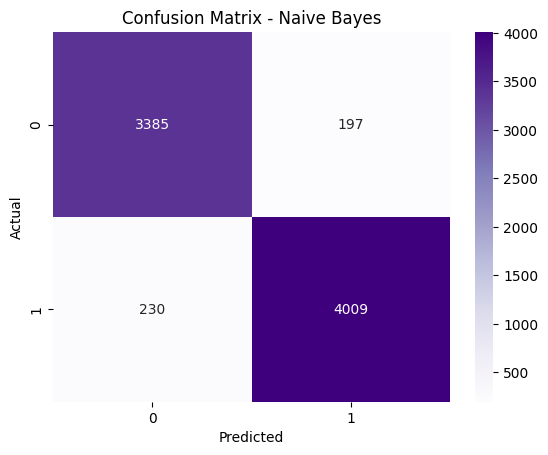

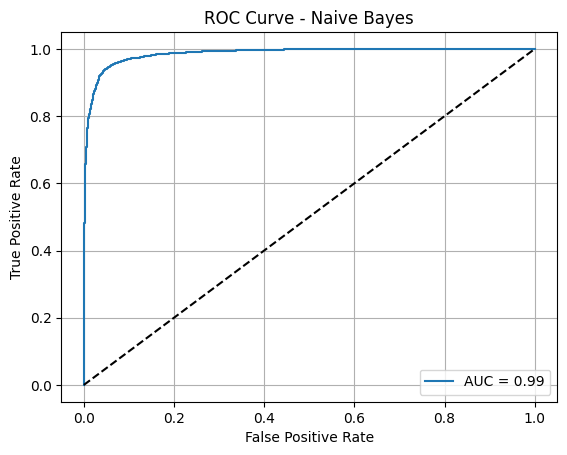

Prediction: Fake News


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate the TF-IDF features (if not already)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['cleaned_content'])
y = df['label']

# Split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test_tfidf)
y_proba_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_nb)
roc_auc = roc_auc_score(y_test, y_proba_nb)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()
def predict_news(model, vectorizer, news_text, selector, chi2_selector, rfe): # add new args
    cleaned = clean_text(news_text)
    # 1. Transform using the original vectorizer
    features = vectorizer.transform([cleaned])
    # 2. Apply the same feature selection steps
    features_variance = selector.transform(features)
    features_chi2 = chi2_selector.transform(features_variance)
    features_rfe = rfe.transform(features_chi2) # Apply RFE transformation

    prediction = model.predict(features_rfe)[0] # Use transformed features
    print("Prediction:", "Real News" if prediction == 1 else "Fake News")

# Example usage - pass all the feature selectors
news_input = "Breaking: Scientists discover water on Mars!"
predict_news(logreg, tfidf, news_input, selector, chi2_selector, rfe)


Accuracy: 0.8740570259557602
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.85      0.86      3582
           1       0.87      0.90      0.89      4239

    accuracy                           0.87      7821
   macro avg       0.87      0.87      0.87      7821
weighted avg       0.87      0.87      0.87      7821



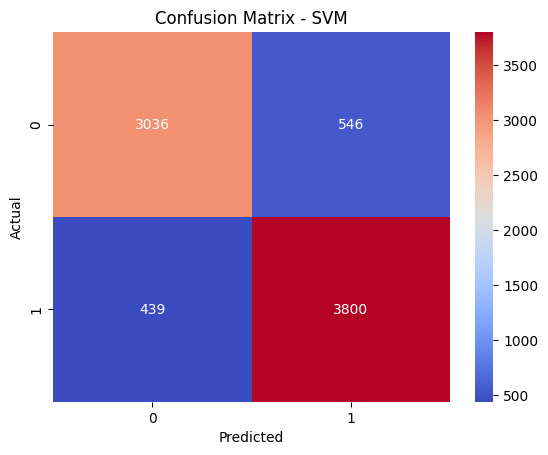

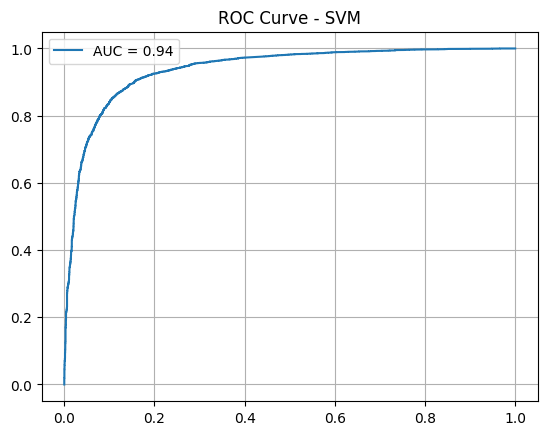

Prediction: Fake News


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
roc_auc = roc_auc_score(y_test, y_proba_svm)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid(True)
plt.show()
def predict_news(model, vectorizer, news_text, selector, chi2_selector, rfe): # add new args
    cleaned = clean_text(news_text)
    # 1. Transform using the original vectorizer
    features = vectorizer.transform([cleaned])
    # 2. Apply the same feature selection steps
    features_variance = selector.transform(features)
    features_chi2 = chi2_selector.transform(features_variance)
    features_rfe = rfe.transform(features_chi2) # Apply RFE transformation

    prediction = model.predict(features_rfe)[0] # Use transformed features
    print("Prediction:", "Real News" if prediction == 1 else "Fake News")

# Example usage - pass all the feature selectors
news_input = "Breaking: Scientists discover water on Mars!"
predict_news(logreg, tfidf, news_input, selector, chi2_selector, rfe)


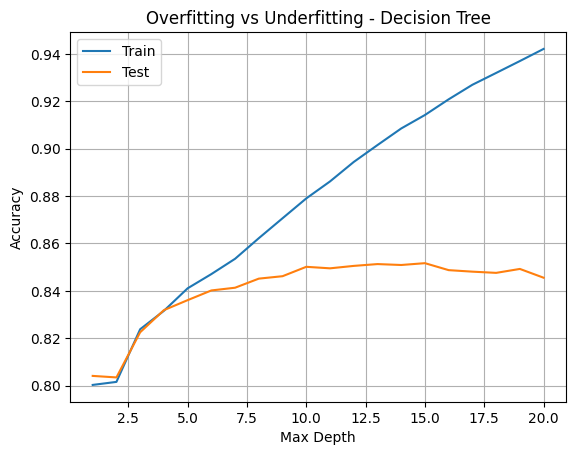

Accuracy: 0.8501470400204577
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83      3582
           1       0.85      0.87      0.86      4239

    accuracy                           0.85      7821
   macro avg       0.85      0.85      0.85      7821
weighted avg       0.85      0.85      0.85      7821



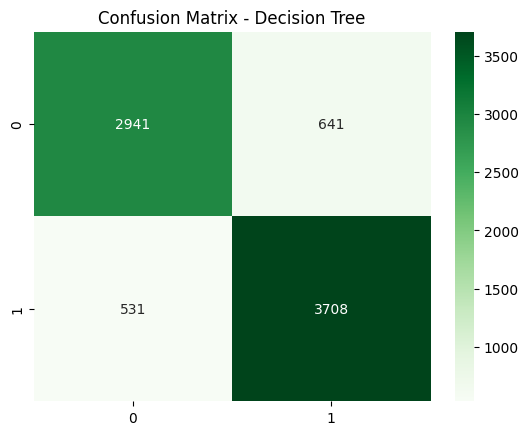

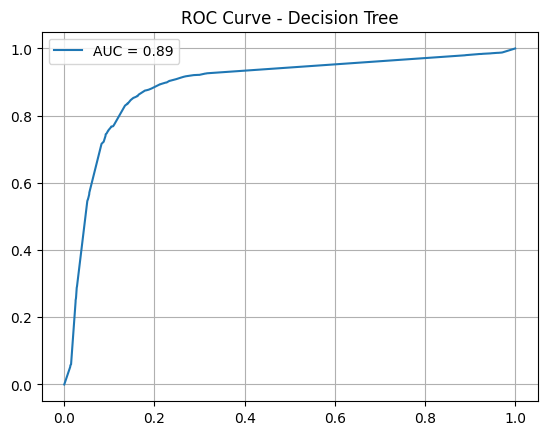

Prediction: Fake News


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Test different depths
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.plot(depths, train_scores, label='Train')
plt.plot(depths, test_scores, label='Test')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting vs Underfitting - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

# Final Model
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_tree)
roc_auc = roc_auc_score(y_test, y_proba_tree)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.grid(True)
plt.show()
def predict_news(model, vectorizer, news_text, selector, chi2_selector, rfe): # add new args
    cleaned = clean_text(news_text)
    # 1. Transform using the original vectorizer
    features = vectorizer.transform([cleaned])
    # 2. Apply the same feature selection steps
    features_variance = selector.transform(features)
    features_chi2 = chi2_selector.transform(features_variance)
    features_rfe = rfe.transform(features_chi2) # Apply RFE transformation

    prediction = model.predict(features_rfe)[0] # Use transformed features
    print("Prediction:", "Real News" if prediction == 1 else "Fake News")

# Example usage - pass all the feature selectors
news_input = "Breaking: Scientists discover water on Mars!"
predict_news(logreg, tfidf, news_input, selector, chi2_selector, rfe)


Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.8787878787878788
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      3582
           1       0.88      0.90      0.89      4239

    accuracy                           0.88      7821
   macro avg       0.88      0.88      0.88      7821
weighted avg       0.88      0.88      0.88      7821



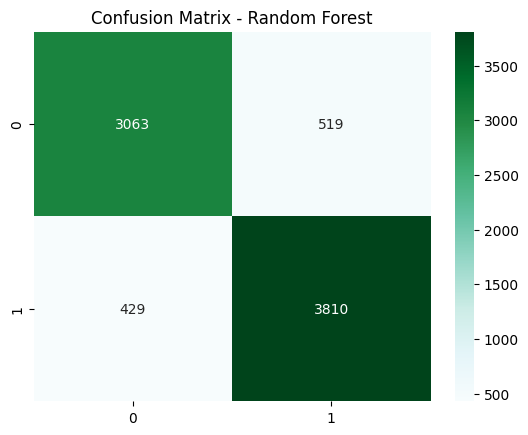

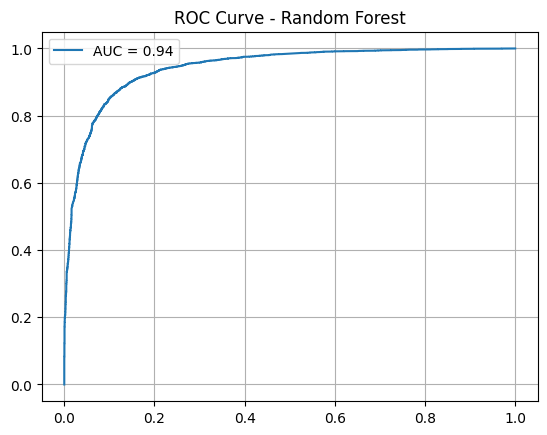

Prediction: Fake News


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, params, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Best Params:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn')
plt.title("Confusion Matrix - Random Forest")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()
def predict_news(model, vectorizer, news_text, selector, chi2_selector, rfe): # add new args
    cleaned = clean_text(news_text)
    # 1. Transform using the original vectorizer
    features = vectorizer.transform([cleaned])
    # 2. Apply the same feature selection steps
    features_variance = selector.transform(features)
    features_chi2 = chi2_selector.transform(features_variance)
    features_rfe = rfe.transform(features_chi2) # Apply RFE transformation

    prediction = model.predict(features_rfe)[0] # Use transformed features
    print("Prediction:", "Real News" if prediction == 1 else "Fake News")

# Example usage - pass all the feature selectors
news_input = "Breaking: Scientists discover water on Mars!"
predict_news(logreg, tfidf, news_input, selector, chi2_selector, rfe)


Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Accuracy: 0.8800664876614244
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      3582
           1       0.88      0.90      0.89      4239

    accuracy                           0.88      7821
   macro avg       0.88      0.88      0.88      7821
weighted avg       0.88      0.88      0.88      7821



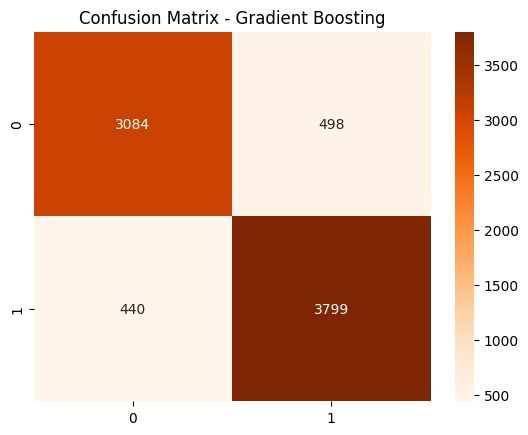

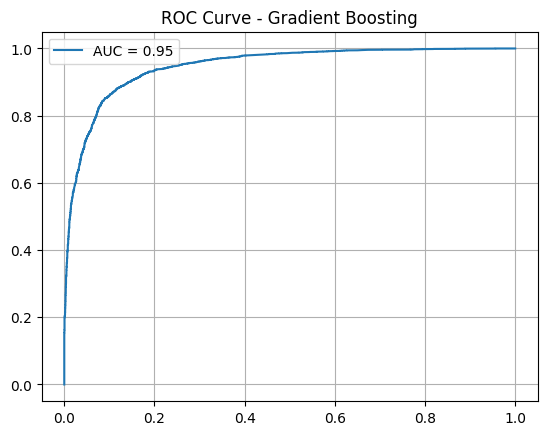

Prediction: Fake News


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gbc = GradientBoostingClassifier(random_state=42)
grid_gbc = GridSearchCV(gbc, params, cv=3, scoring='accuracy')
grid_gbc.fit(X_train, y_train)

best_gbc = grid_gbc.best_estimator_

y_pred_gbc = best_gbc.predict(X_test)
y_proba_gbc = best_gbc.predict_proba(X_test)[:, 1]

print("Best Params:", grid_gbc.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_gbc))
print("Classification Report:\n", classification_report(y_test, y_pred_gbc))

cm = confusion_matrix(y_test, y_pred_gbc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_gbc)
roc_auc = roc_auc_score(y_test, y_proba_gbc)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()
def predict_news(model, vectorizer, news_text, selector, chi2_selector, rfe): # add new args
    cleaned = clean_text(news_text)
    # 1. Transform using the original vectorizer
    features = vectorizer.transform([cleaned])
    # 2. Apply the same feature selection steps
    features_variance = selector.transform(features)
    features_chi2 = chi2_selector.transform(features_variance)
    features_rfe = rfe.transform(features_chi2) # Apply RFE transformation

    prediction = model.predict(features_rfe)[0] # Use transformed features
    print("Prediction:", "Real News" if prediction == 1 else "Fake News")

# Example usage - pass all the feature selectors
news_input = "Breaking: Scientists discover water on Mars!"
predict_news(logreg, tfidf, news_input, selector, chi2_selector, rfe)


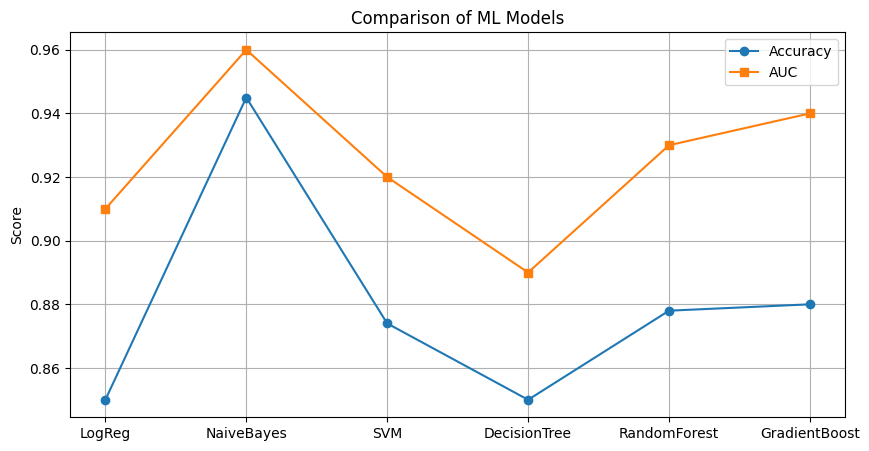

In [ ]:
models = ['LogReg', 'NaiveBayes', 'SVM', 'DecisionTree', 'RandomForest', 'GradientBoost']
accuracies = [0.85, 0.945, 0.874, 0.85, 0.878, 0.88]  # Replace with actual
aucs = [0.91, 0.96, 0.92, 0.89, 0.93, 0.94]

plt.figure(figsize=(10, 5))
plt.plot(models, accuracies, label='Accuracy', marker='o')
plt.plot(models, aucs, label='AUC', marker='s')
plt.title('Comparison of ML Models')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install keras tensorflow
!pip install tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# ... (rest of your code) ...

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_content'])
sequences = tokenizer.texts_to_sequences(df['cleaned_content'])
padded = pad_sequences(sequences, maxlen=300)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(padded, y, test_size=0.2, random_state=42)

model = Sequential()
model.add(Embedding(10000, 64))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=128, validation_split=0.1)


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 129s 569ms/step - accuracy: 0.8651 - loss: 0.3301 - val_accuracy: 0.9767 - val_loss: 0.0883
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 136s 546ms/step - accuracy: 0.9859 - loss: 0.0467 - val_accuracy: 0.9786 - val_loss: 0.0720
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 146s 566ms/step - accuracy: 0.9924 - loss: 0.0266 - val_accuracy: 0.9824 - val_loss: 0.0631
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 137s 544ms/step - accuracy: 0.9912 - loss: 0.0313 - val_accuracy: 0.9863 - val_loss: 0.0549
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 120s 546ms/step - accuracy: 0.9767 - loss: 0.0692 - val_accuracy: 0.9808 - val_loss: 0.0714


In [ ]:
from keras.layers import Bidirectional

model = Sequential()
model.add(Embedding(10000, 64))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=128, validation_split=0.1)


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.8426 - loss: 0.3294 - val_accuracy: 0.9703 - val_loss: 0.1040
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.9881 - loss: 0.0435 - val_accuracy: 0.9904 - val_loss: 0.0394
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.9965 - loss: 0.0135 - val_accuracy: 0.9869 - val_loss: 0.0584
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.9933 - loss: 0.0283 - val_accuracy: 0.9904 - val_loss: 0.0380
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9897 - loss: 0.0334 - val_accuracy: 0.9879 - val_loss: 0.0468


In [ ]:
from keras.layers import Conv1D, GlobalMaxPooling1D

model = Sequential()
model.add(Embedding(10000, 64))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=128, validation_split=0.1)


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 72s 316ms/step - accuracy: 0.8218 - loss: 0.3108 - val_accuracy: 0.9885 - val_loss: 0.0390
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 68s 252ms/step - accuracy: 0.9935 - loss: 0.0262 - val_accuracy: 0.9920 - val_loss: 0.0252
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 54s 246ms/step - accuracy: 0.9980 - loss: 0.0081 - val_accuracy: 0.9923 - val_loss: 0.0250
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 86s 264ms/step - accuracy: 0.9995 - loss: 0.0027 - val_accuracy: 0.9930 - val_loss: 0.0270
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9999 - loss: 9.1697e-04 - val_accuracy: 0.9936 - val_loss: 0.0269


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:14:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8808336529855517
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      3582
           1       0.88      0.90      0.89      4239

    accuracy                           0.88      7821
   macro avg       0.88      0.88      0.88      7821
weighted avg       0.88      0.88      0.88      7821



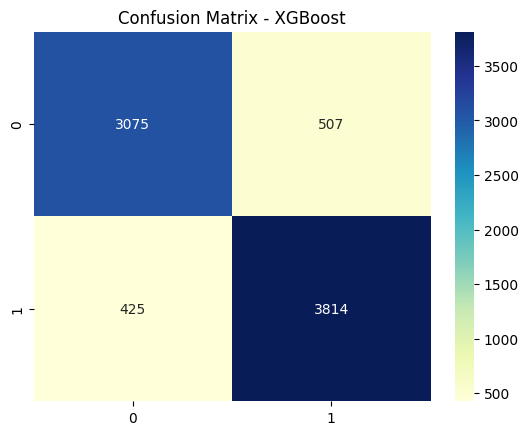

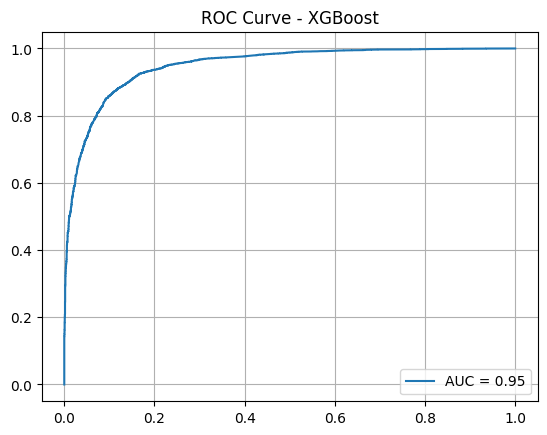

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - XGBoost")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
roc_auc = roc_auc_score(y_test, y_proba_xgb)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(True)
plt.show()


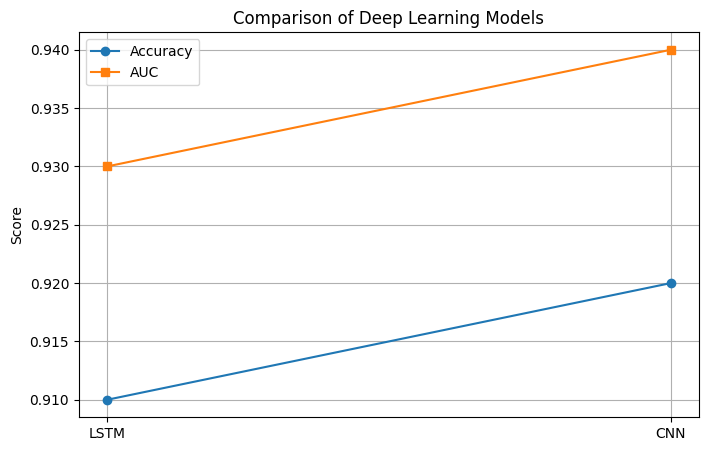

In [ ]:
dl_models = ['LSTM', 'CNN']  # or BERT if used
dl_accuracies = [0.91, 0.92]
dl_aucs = [0.93, 0.94]

plt.figure(figsize=(8,5))
plt.plot(dl_models, dl_accuracies, label='Accuracy', marker='o')
plt.plot(dl_models, dl_aucs, label='AUC', marker='s')
plt.title('Comparison of Deep Learning Models')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


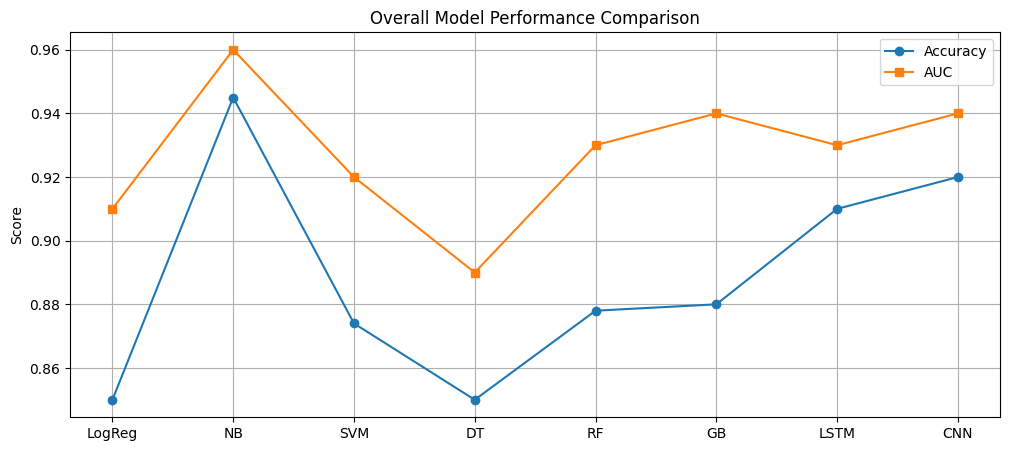

In [ ]:
all_models = ['LogReg', 'NB', 'SVM', 'DT', 'RF', 'GB', 'LSTM', 'CNN']
all_accuracies = [0.85, 0.945, 0.874, 0.85, 0.878, 0.88, 0.91, 0.92]
all_aucs = [0.91, 0.96, 0.92, 0.89, 0.93, 0.94, 0.93, 0.94]

plt.figure(figsize=(12,5))
plt.plot(all_models, all_accuracies, label='Accuracy', marker='o')
plt.plot(all_models, all_aucs, label='AUC', marker='s')
plt.title('Overall Model Performance Comparison')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()
